# Grain Price Analysis: Behavior Over Time, with a Focus on August

This notebook looks at how USDA's **Avg. Farm Price** estimate behaves for the six grain commodities tracked in WASDE (Corn, Wheat, Sorghum, Barley, Oats, Rice) across the life of a marketing year, and specifically tests whether the **August WASDE report** behaves differently from other months.

August is a natural candidate for a distinct effect: it's the report that (for corn, soybeans, and other row crops) introduces the first field-survey-based yield estimate for the current marketing year, rather than a trend/weather-based projection.

Two views:

1. **Revision paths** — for each commodity, how the price estimate for a given marketing year evolves report-by-report from its first projection through finalization, with the August release marked on each line.
2. **Seasonality of revision size** — across all years, how large is the average month-over-month change in the price estimate, broken out by calendar month.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

df = pd.read_csv("../../data/processed/us_df.csv")

GRAINS = ["Corn", "Wheat", "Sorghum", "Barley", "Oats", "Rice, Long"]

# WASDE reports "Avg. farm price" / "Avg. Farm Price" for each grain: a marketing-year
# average price that gets revised release-to-release before being finalized.
mask = df["Commodity"].isin(GRAINS) & (df["Attribute"].str.lower() == "avg. farm price")
price = df.loc[mask, ["Commodity", "MarketYear", "ReportDate", "Value", "ProjEstFlag"]].copy()
price["ReportDate_dt"] = pd.to_datetime(price["ReportDate"], format="%B %Y")
price = price.sort_values(["Commodity", "MarketYear", "ReportDate_dt"])

price.head()

,Commodity,MarketYear,ReportDate,Value,ProjEstFlag,ReportDate_dt
769,Barley,2007/08,April 2010,4.020,NaN,2010-04-01
811,Barley,2008/09,April 2010,5.370,Est.,2010-04-01
2275,Barley,2008/09,May 2010,5.370,NaN,2010-05-01
3740,Barley,2008/09,June 2010,5.370,NaN,2010-06-01
5201,Barley,2008/09,July 2010,5.370,NaN,2010-07-01


In [2]:
# Each marketing year's price estimate starts as "Proj." (roughly a year out), becomes
# "Est." once the marketing year is underway, then finalizes (ProjEstFlag -> blank) and
# repeats unchanged in every later report. We trim each (Commodity, MarketYear) series to
# the active window -- first appearance through the first finalized reading -- so the
# revision path reflects real changes, not a flat tail of repeated final values.
price["is_final"] = price["ProjEstFlag"].isna()
price["final_cum"] = price.groupby(["Commodity", "MarketYear"])["is_final"].cumsum()
active = price[price["final_cum"] <= 1].copy()

active["t"] = active.groupby(["Commodity", "MarketYear"]).cumcount()
active["month_num"] = active["ReportDate_dt"].dt.month
active["is_august"] = active["month_num"] == 8
active["revision"] = active.groupby(["Commodity", "MarketYear"])["Value"].diff()

active[["Commodity", "MarketYear", "ReportDate", "t", "Value", "revision", "is_august"]].head(10)

,Commodity,MarketYear,ReportDate,t,Value,revision,is_august
769,Barley,2007/08,April 2010,0,4.020,NaN,False
811,Barley,2008/09,April 2010,0,5.370,NaN,False
2275,Barley,2008/09,May 2010,1,5.370,0.000,False
2317,Barley,2009/10,May 2010,0,4.650,NaN,False
3782,Barley,2009/10,June 2010,1,4.650,0.000,False
5243,Barley,2009/10,July 2010,2,4.660,0.010,False
6746,Barley,2009/10,August 2010,3,4.660,0.000,True
8248,Barley,2009/10,September 2010,4,4.660,0.000,False
9744,Barley,2009/10,October 2010,5,4.660,0.000,False
11240,Barley,2009/10,November 2010,6,4.660,0.000,False


## 1. Revision paths, with August marked

For each commodity, the lines below are the last several marketing years' price estimates traced from first projection to finalization (older years lighter, most recent year darkest). The orange dot on each line is the August WASDE release.

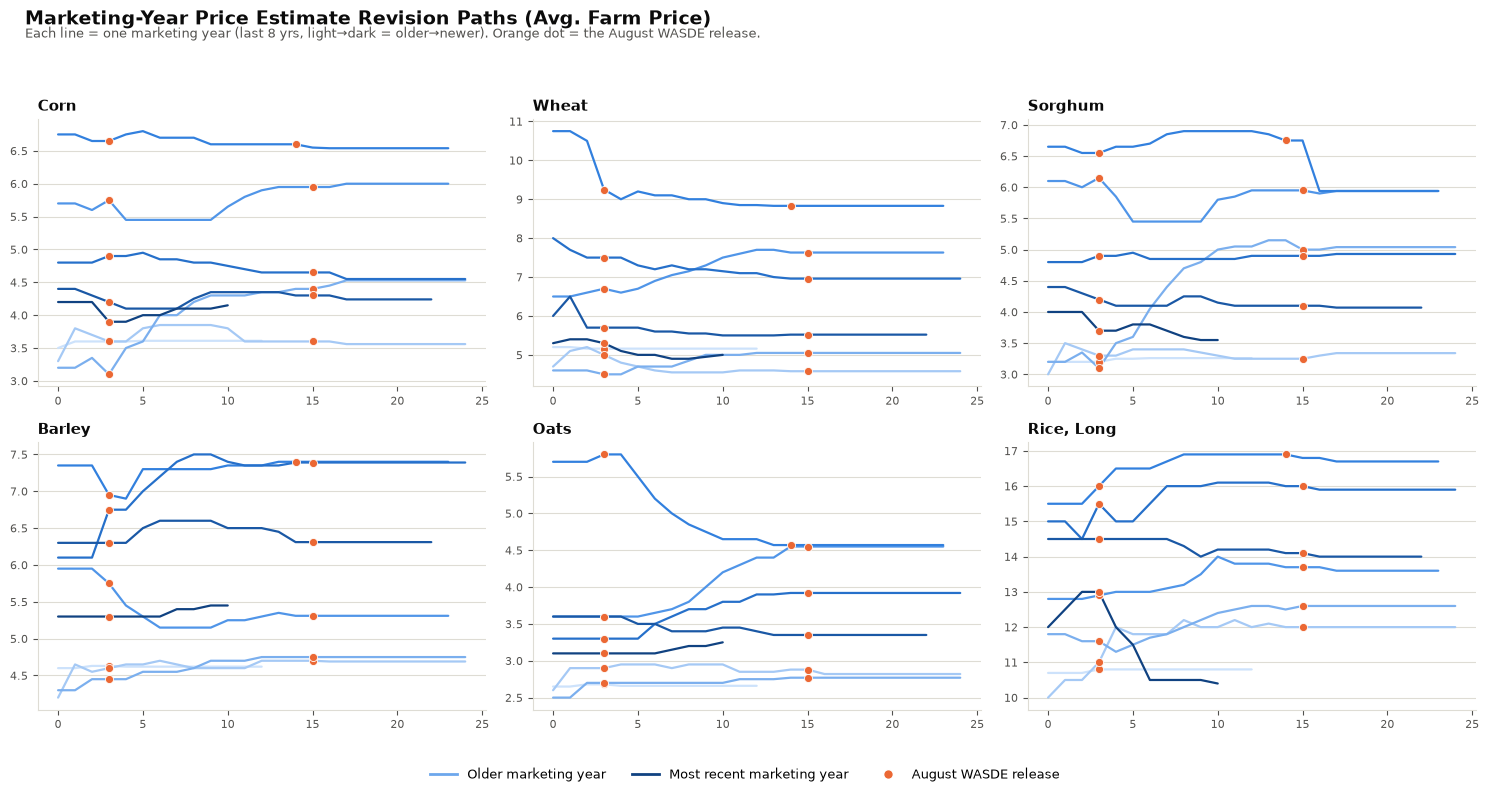

In [3]:
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
ACCENT = "#eb6834"  # August highlight
GRID = "#dedcd4"
TEXT_SECONDARY = "#52514e"
TEXT_PRIMARY = "#0b0b0b"
N_YEARS = 8  # most recent marketing years shown per commodity

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
cmap = LinearSegmentedColormap.from_list("blue_seq", BLUE_RAMP)

for ax, commodity in zip(axes, GRAINS):
    cdf = active[active["Commodity"] == commodity]
    years = sorted(cdf["MarketYear"].unique())[-N_YEARS:]
    for i, yr in enumerate(years):
        ydf = cdf[cdf["MarketYear"] == yr].sort_values("t")
        color = cmap(i / max(len(years) - 1, 1))
        ax.plot(ydf["t"], ydf["Value"], color=color, linewidth=1.6, solid_capstyle="round", zorder=2)
        aug = ydf[ydf["is_august"]]
        ax.scatter(aug["t"], aug["Value"], color=ACCENT, s=34, zorder=5, edgecolor="white", linewidth=0.6)

    ax.set_title(commodity, fontsize=11, color=TEXT_PRIMARY, loc="left", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=8)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

fig.suptitle("Marketing-Year Price Estimate Revision Paths (Avg. Farm Price)",
             fontsize=14, fontweight="bold", color=TEXT_PRIMARY, x=0.02, ha="left")
fig.text(0.02, 0.945,
         f"Each line = one marketing year (last {N_YEARS} yrs, light→dark = older→newer). Orange dot = the August WASDE release.",
         fontsize=9.5, color=TEXT_SECONDARY)

legend_elems = [
    Line2D([0], [0], color=BLUE_RAMP[2], lw=2, label="Older marketing year"),
    Line2D([0], [0], color=BLUE_RAMP[-1], lw=2, label="Most recent marketing year"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=ACCENT, markeredgecolor="white", markersize=7, label="August WASDE release"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=3, frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, 0.0))

fig.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.show()

## 2. Is August actually different? Revision size by calendar month

For every report-to-report step in the active windows above, take the absolute change in the price estimate, then average by the calendar month of the *later* report. This isolates which month of the year tends to bring the biggest re-pricing, independent of which marketing year it belongs to.

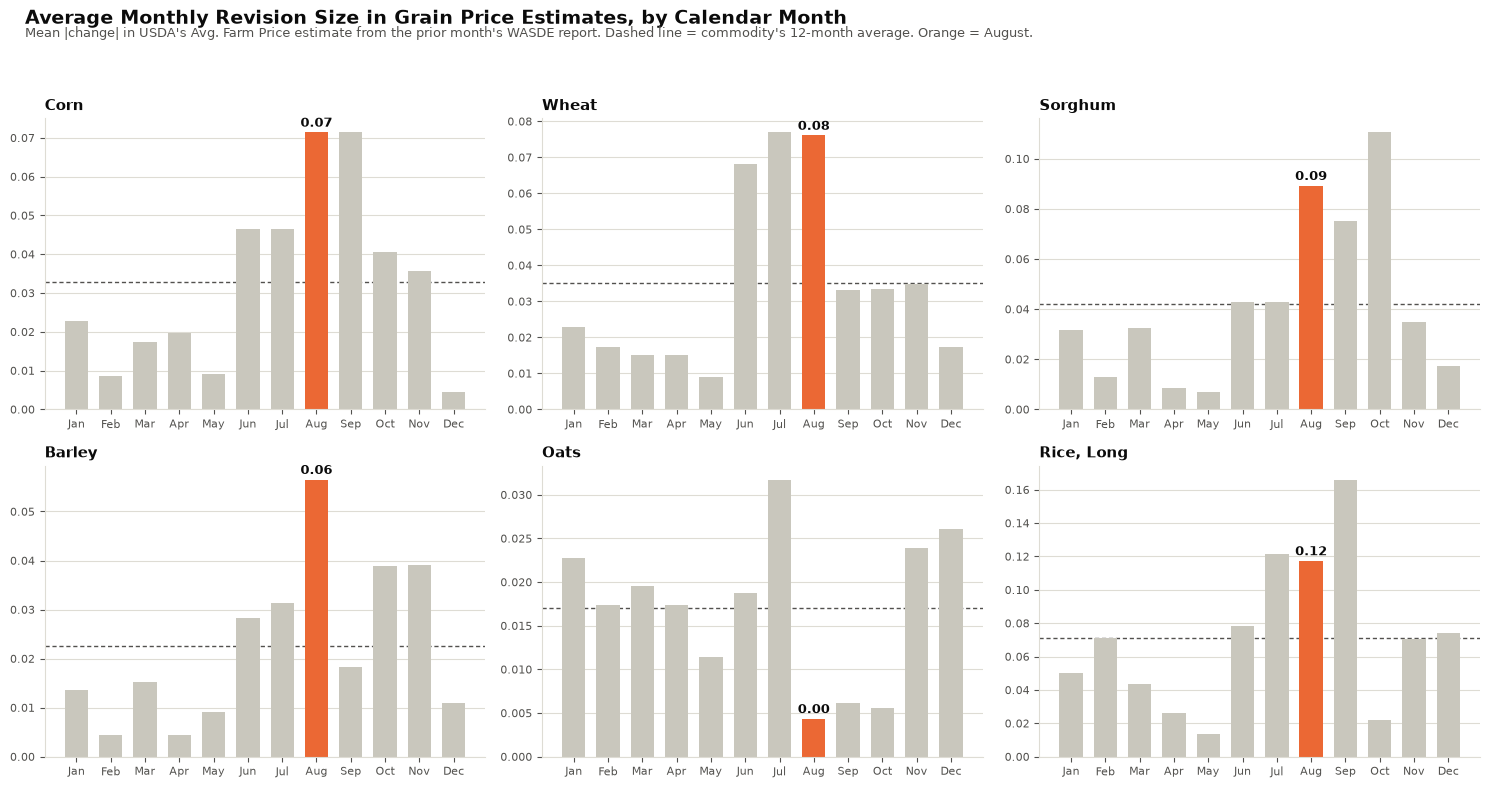

In [4]:
abs_rev = active.dropna(subset=["revision"]).copy()
abs_rev["abs_revision"] = abs_rev["revision"].abs()

MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
GRAY = "#c9c7bd"

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, commodity in zip(axes, GRAINS):
    cdf = abs_rev[abs_rev["Commodity"] == commodity]
    by_month = cdf.groupby("month_num")["abs_revision"].mean().reindex(range(1, 13))
    colors = [ACCENT if m == 8 else GRAY for m in range(1, 13)]
    ax.bar(MONTH_LABELS, by_month.values, color=colors, width=0.68, zorder=2)

    overall_mean = by_month.mean()
    ax.axhline(overall_mean, color=TEXT_SECONDARY, linewidth=1, linestyle=(0, (3, 2)), zorder=1)

    aug_val = by_month.loc[8]
    ax.annotate(f"{aug_val:.2f}", xy=(7, aug_val), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9, color=TEXT_PRIMARY, fontweight="bold")

    ax.set_title(commodity, fontsize=11, color=TEXT_PRIMARY, loc="left", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=8)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

fig.suptitle("Average Monthly Revision Size in Grain Price Estimates, by Calendar Month",
             fontsize=14, fontweight="bold", color=TEXT_PRIMARY, x=0.02, ha="left")
fig.text(0.02, 0.945,
         "Mean |change| in USDA's Avg. Farm Price estimate from the prior month's WASDE report. Dashed line = commodity's 12-month average. Orange = August.",
         fontsize=9.5, color=TEXT_SECONDARY)

fig.tight_layout(rect=[0, 0.0, 1, 0.93])
plt.show()

In [5]:
# Where does August rank among the 12 months for each commodity? (1 = biggest average revision)
pivot = abs_rev.groupby(["Commodity", "month_num"])["abs_revision"].mean().unstack()
pivot.columns = pd.to_datetime(pivot.columns, format="%m").strftime("%b")

summary = pd.DataFrame({
    "August mean |revision|": pivot["Aug"],
    "12-month mean": pivot.mean(axis=1),
    "August rank (1=highest)": pivot.rank(axis=1, ascending=False)["Aug"].astype(int),
}).reindex(GRAINS)

summary

,August mean |revision|,12-month mean,August rank (1=highest)
Commodity,,,
Corn,0.071,0.033,1
Wheat,0.076,0.035,2
Sorghum,0.089,0.042,2
Barley,0.057,0.022,1
Oats,0.004,0.017,12
"Rice, Long",0.117,0.071,3


## Takeaways

- **Corn, Wheat, Sorghum, and Barley** all show August as their #1 or #2 highest-revision month, running roughly 2x their 12-month average. This lines up with the August WASDE report's role as the first field-survey-based yield estimate of the marketing year for row crops.
- **Rice** shows a real but smaller August effect (#3 of 12); its harvest and survey calendar is offset relative to corn/wheat, so July and September pick up some of what August does for the other grains.
- **Oats is the outlier** — August is its *lowest*-revision month. Oats is a minor, thinly surveyed crop with a much earlier harvest, so it doesn't get the same August data injection the major row crops do.
- Net: "what grains do in August" is not one story — it's a strong, consistent re-pricing event for the major feed grains and wheat, a milder version for rice, and largely absent for oats.